# Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor

from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Data Loading

In [2]:
booknow_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
booknow_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
booknow_visits = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
cinePOS_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
cinePOS_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
date_info = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
movie_theater_id_relation = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
submission = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')

# Basic Information

In [3]:
dataframes = {
    "booknow_booking": booknow_booking,
    "booknow_theaters": booknow_theaters,
    "booknow_visits": booknow_visits,
    "cinePOS_booking": cinePOS_booking,
    "cinePOS_theaters": cinePOS_theaters,
    "date_info": date_info,
    "movie_theater_id_relation": movie_theater_id_relation,
    "submission": submission
}

In [4]:
for name, df in dataframes.items():
    print(f"\n--- Info for {name} ---")
    df.info()


--- Info for booknow_booking ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB

--- Info for booknow_theaters ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  314 non-null    object 
 1   theater_type     829 non-null    object 
 2   theater_area     829 non-null    object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB

--- Info for book

In [5]:
for name, df in dataframes.items():
    print(f"{name} columns:", df.columns.tolist())

booknow_booking columns: ['book_theater_id', 'show_datetime', 'booking_datetime', 'tickets_booked']
booknow_theaters columns: ['book_theater_id', 'theater_type', 'theater_area', 'latitude', 'longitude']
booknow_visits columns: ['book_theater_id', 'show_date', 'audience_count']
cinePOS_booking columns: ['cine_theater_id', 'show_datetime', 'booking_datetime', 'tickets_sold']
cinePOS_theaters columns: ['cine_theater_id', 'theater_type', 'theater_area', 'latitude', 'longitude']
date_info columns: ['show_date', 'day_of_week']
movie_theater_id_relation columns: ['book_theater_id', 'cine_theater_id']
submission columns: ['ID', 'audience_count']


In [6]:
for name, df in dataframes.items():
    print(f"Shape of {name}: {df.shape}")

Shape of booknow_booking: (68336, 4)
Shape of booknow_theaters: (829, 5)
Shape of booknow_visits: (214046, 3)
Shape of cinePOS_booking: (1641966, 4)
Shape of cinePOS_theaters: (4690, 5)
Shape of date_info: (547, 2)
Shape of movie_theater_id_relation: (150, 2)
Shape of submission: (38062, 2)


# Descriptive Statistics

In [7]:
for name, df in dataframes.items():
    print(f"\n--- Descriptive Statistics for {name} ---")
    print(df.describe())


--- Descriptive Statistics for booknow_booking ---
       tickets_booked
count    68336.000000
mean         4.425808
std          4.808945
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        100.000000

--- Descriptive Statistics for booknow_theaters ---
         latitude   longitude
count  829.000000  829.000000
mean    23.000000   79.000000
std      0.833863    1.460388
min     22.025970   76.112098
25%     22.619233   78.170501
50%     23.004410   79.908065
75%     23.018784   79.934515
max     26.349436   81.743235

--- Descriptive Statistics for booknow_visits ---
       audience_count
count   214046.000000
mean        41.616568
std         32.834918
min          2.000000
25%         18.000000
50%         34.000000
75%         58.000000
max       1350.000000

--- Descriptive Statistics for cinePOS_booking ---
       tickets_sold
count  1.641966e+06
mean   4.987345e+00
std    5.234901e+00
min    1.000000e+00
25%    2.000000e+00
50%   

# Checking for Missing Values and Duplicates

In [8]:
for name, df in dataframes.items():
    print(f"\n--- Missing Values for {name} ---")
    print(df.isnull().sum())
    print(f"\n--- Duplicate Rows for {name} ---")
    print(df.duplicated().sum())


--- Missing Values for booknow_booking ---
book_theater_id     0
show_datetime       0
booking_datetime    0
tickets_booked      0
dtype: int64

--- Duplicate Rows for booknow_booking ---
2042

--- Missing Values for booknow_theaters ---
book_theater_id    515
theater_type         0
theater_area         0
latitude             0
longitude            0
dtype: int64

--- Duplicate Rows for booknow_theaters ---
354

--- Missing Values for booknow_visits ---
book_theater_id    0
show_date          0
audience_count     0
dtype: int64

--- Duplicate Rows for booknow_visits ---
10

--- Missing Values for cinePOS_booking ---
cine_theater_id     0
show_datetime       0
booking_datetime    0
tickets_sold        0
dtype: int64

--- Duplicate Rows for cinePOS_booking ---
12541

--- Missing Values for cinePOS_theaters ---
cine_theater_id       0
theater_type          0
theater_area          0
latitude           3861
longitude          3861
dtype: int64

--- Duplicate Rows for cinePOS_theaters ---
0

# Visualizing Missing Values

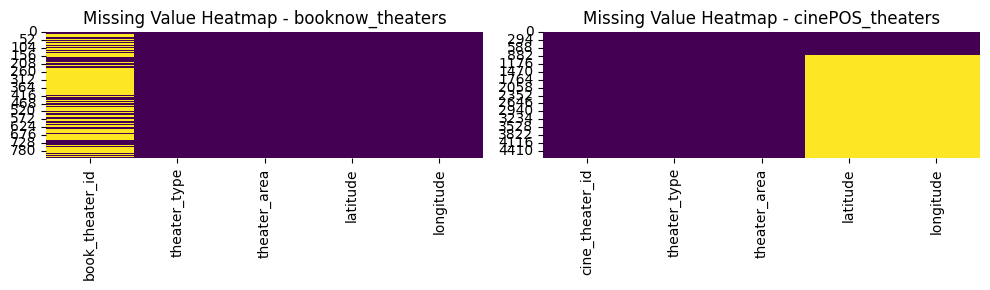

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.heatmap(dataframes['booknow_theaters'].isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title("Missing Value Heatmap - booknow_theaters")

sns.heatmap(dataframes['cinePOS_theaters'].isnull(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title("Missing Value Heatmap - cinePOS_theaters")

plt.tight_layout()
plt.show()

# EDA & Data Preprocessing

In [10]:
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'], errors='coerce', format='mixed').dt.date
booknow_booking = booknow_booking.groupby(['book_theater_id','show_datetime']).agg({'tickets_booked': 'sum'})
booknow_booking = booknow_booking.reset_index()
booknow_visits ['show_date'] = pd.to_datetime(booknow_visits ['show_date'], errors='coerce', format='mixed').dt.date

cinePOS_booking['show_datetime'] = pd.to_datetime(cinePOS_booking['show_datetime'], errors='coerce', format='mixed').dt.date
cinePOS_booking['booking_datetime'] = pd.to_datetime(cinePOS_booking['booking_datetime'], errors='coerce', format='mixed').dt.date
cinePOS_booking = cinePOS_booking.groupby(['cine_theater_id','show_datetime']).agg({'tickets_sold': 'sum'})
cinePOS_booking = cinePOS_booking.reset_index()
cinepos = pd.merge(cinePOS_booking,cinePOS_theaters,how="left",on= 'cine_theater_id')

booknow = pd.merge(booknow_visits,booknow_booking,how="left",left_on= ['book_theater_id','show_date'], right_on = ['book_theater_id','show_datetime'])
booknow = pd.merge(booknow,booknow_theaters,how="left",on='book_theater_id')
booknow = pd.merge(booknow,movie_theater_id_relation,how="left",on= 'book_theater_id')

df = pd.merge(booknow,cinepos,how="left",left_on= ['cine_theater_id','show_date'],right_on = ['cine_theater_id','show_datetime'])

In [11]:
df.info()
df.head(5)
df.describe()
print(min(df['show_date']),max(df['show_date']))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   book_theater_id  214046 non-null  object 
 1   show_date        214046 non-null  object 
 2   audience_count   214046 non-null  int64  
 3   show_datetime_x  21041 non-null   object 
 4   tickets_booked   21041 non-null   float64
 5   theater_type_x   80150 non-null   object 
 6   theater_area_x   80150 non-null   object 
 7   latitude_x       80150 non-null   float64
 8   longitude_x      80150 non-null   float64
 9   cine_theater_id  38976 non-null   object 
 10  show_datetime_y  11150 non-null   object 
 11  tickets_sold     11150 non-null   float64
 12  theater_type_y   5367 non-null    object 
 13  theater_area_y   5367 non-null    object 
 14  latitude_y       1036 non-null    float64
 15  longitude_y      1036 non-null    float64
dtypes: float64(6), int64(1), object(9)
mem

## Feature Engineering

In [12]:
df['is_weekday'] = pd.to_datetime(df['show_date']).dt.weekday < 5
df['is_weekday']= df['is_weekday'].astype(int)

df['year'] = pd.to_datetime(df['show_date']).dt.year
df['month'] = pd.to_datetime(df['show_date']).dt.month
df['date'] = pd.to_datetime(df['show_date']).dt.day
df['daynum'] = pd.to_datetime(df['show_date']).dt.dayofweek
df['week'] = pd.to_datetime(df['show_date']).dt.isocalendar().week

print(df[df['year'] == 2023]['book_theater_id'].nunique())
print(df[df['year'] == 2024]['book_theater_id'].nunique())
df['book_theater_id'].nunique()

819
818


826

## Imputation

In [13]:
df['theater_type_x'] = df['theater_type_x'].fillna(df['theater_type_y'])
df['theater_area_x'] = df['theater_area_x'].fillna(df['theater_area_y'])
df['latitude_x'] = df['latitude_x'].fillna(df['latitude_y'])
df['longitude_x'] = df['longitude_x'].fillna(df['longitude_y'])

df = df.drop(columns=['show_datetime_x','cine_theater_id',
                      'show_datetime_y','theater_type_y',
                     'theater_area_y','latitude_y','longitude_y'])

type_mapping = (
    df[df['theater_type_x'].notna()].groupby('book_theater_id')['theater_type_x']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
)

df['theater_type_x'] = df['theater_type_x'].fillna(df['book_theater_id'].map(type_mapping))

area_mapping = (
    df[df['theater_area_x'].notna()].groupby('book_theater_id')['theater_area_x']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
)

df['theater_area_x'] = df['theater_area_x'].fillna(df['book_theater_id'].map(area_mapping))
df[df['latitude_x'].notna() & df['theater_area_x'].isna()]
df['theater_type_x'] = df['theater_type_x'].fillna(df['theater_type_x'].mode()[0])
df['theater_area_x'] = df['theater_area_x'].fillna(df['theater_area_x'].mode()[0])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   book_theater_id  214046 non-null  object 
 1   show_date        214046 non-null  object 
 2   audience_count   214046 non-null  int64  
 3   tickets_booked   21041 non-null   float64
 4   theater_type_x   214046 non-null  object 
 5   theater_area_x   214046 non-null  object 
 6   latitude_x       80462 non-null   float64
 7   longitude_x      80462 non-null   float64
 8   tickets_sold     11150 non-null   float64
 9   is_weekday       214046 non-null  int64  
 10  year             214046 non-null  int32  
 11  month            214046 non-null  int32  
 12  date             214046 non-null  int32  
 13  daynum           214046 non-null  int32  
 14  week             214046 non-null  UInt32 
dtypes: UInt32(1), float64(4), int32(4), int64(2), object(4)
memory usage: 20.6+ MB


In [14]:
ticket_booked_mapping = (
    df[df['tickets_booked'].notna()]
      .groupby('show_date')['tickets_booked']
      .median()
 )

df['tickets_booked'] = df['tickets_booked'].fillna(
    df['show_date'].map(ticket_booked_mapping)
 )

tickets_sold_mapping = (
    df[df['tickets_sold'].notna()]
      .groupby('show_date')['tickets_sold']
      .median()
 )
df['tickets_sold'] = df['tickets_sold'].fillna(
    df['show_date'].map(tickets_sold_mapping)
 )

df['latitude_x'] = df['latitude_x'].fillna(df['latitude_x'].mode()[0])
df['longitude_x'] = df['longitude_x'].fillna(df['longitude_x'].mode()[0])

df['tickets_booked'] = df['tickets_booked'].fillna(df['tickets_booked'].median())
df['tickets_sold'] = df['tickets_sold'].fillna(df['tickets_sold'].median())

df['book_theater_id'] = df['book_theater_id'].str.extract(r'(\d+)').astype(int)
df['theater_area_x'] = df['theater_area_x'].str.extract(r'(\d+)').astype(int)

## Visualizations

### Correlation Heatmap

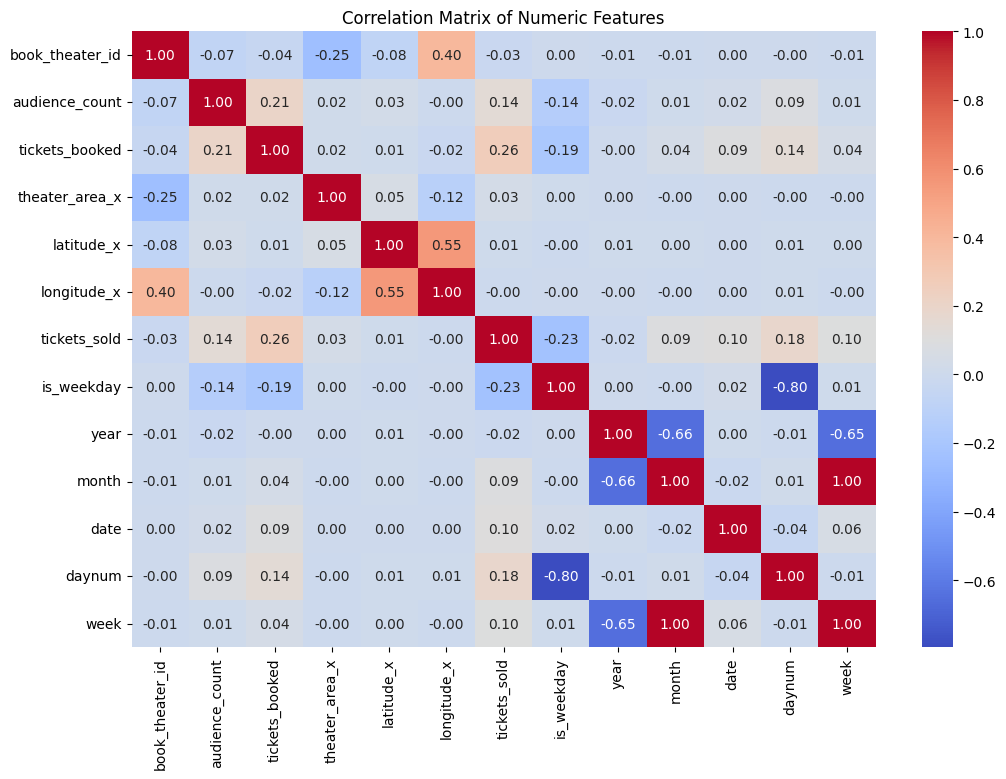

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.dropna().select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

                tickets_booked  audience_count
tickets_booked        1.000000        0.205165
audience_count        0.205165        1.000000


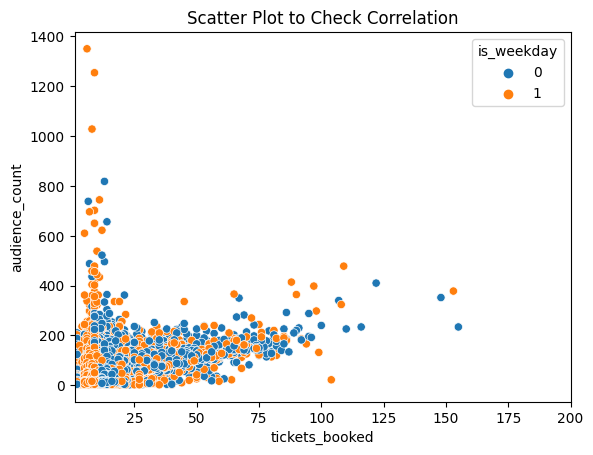

In [16]:
# tickets_booked and audience count correlation check
print(df[['tickets_booked', 'audience_count']].dropna().corr())
sns.scatterplot(data= df[['tickets_booked', 'audience_count','is_weekday']].dropna(), x='tickets_booked', y='audience_count',hue = 'is_weekday')
plt.title("Scatter Plot to Check Correlation")
plt.xlim(1,200)
plt.show()

                tickets_sold  audience_count
tickets_sold        1.000000        0.140756
audience_count      0.140756        1.000000


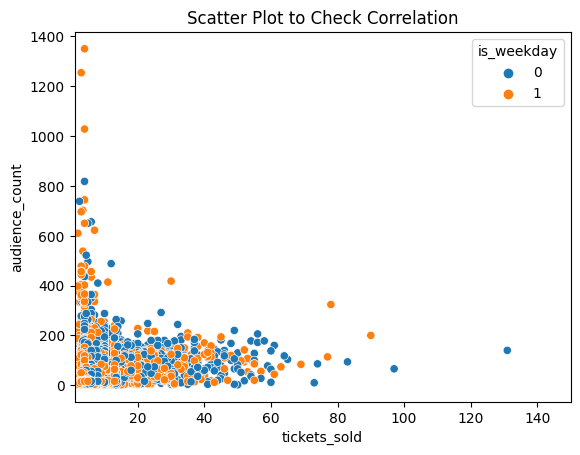

In [17]:
# tickets_sold  and audience count correlation check
print(df[['tickets_sold', 'audience_count']].dropna().corr())
sns.scatterplot(data= df[['tickets_sold', 'audience_count','is_weekday']].dropna(), x='tickets_sold', y='audience_count', hue = 'is_weekday')
plt.title("Scatter Plot to Check Correlation")
plt.xlim(1,150)
plt.show()

                tickets_sold  tickets_booked
tickets_sold        1.000000        0.257077
tickets_booked      0.257077        1.000000


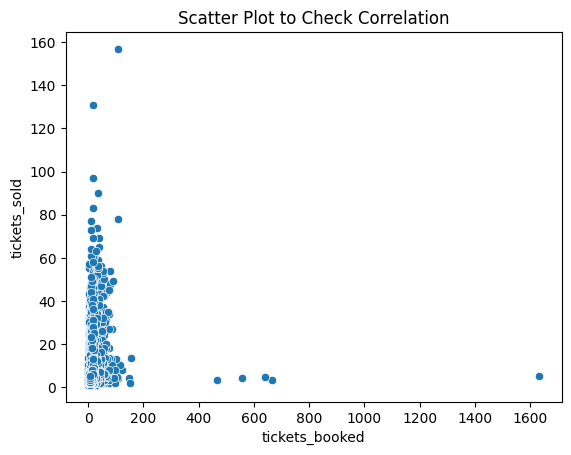

In [18]:
# tickets_sold  and tickets_booked correlation check
print(df[['tickets_sold', 'tickets_booked']].dropna().corr())
sns.scatterplot(data=df[['tickets_sold', 'tickets_booked']].dropna(), x='tickets_booked', y='tickets_sold')
plt.title("Scatter Plot to Check Correlation")
plt.show()

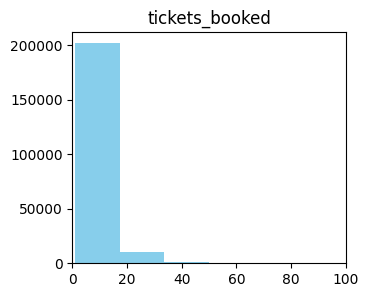

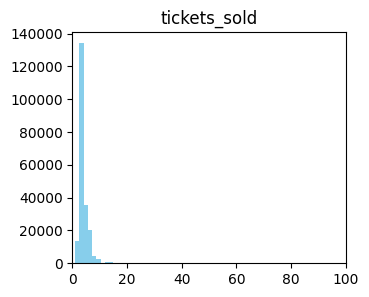

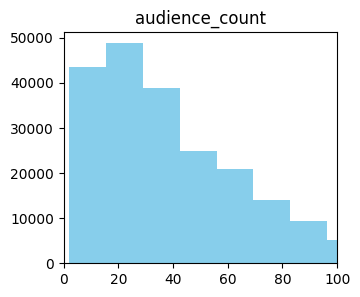

In [19]:
# Distribution analysis

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.hist(df['tickets_booked'].dropna(), bins=100, color='skyblue')
plt.xlim(0,100)
plt.title("tickets_booked")

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 2)
plt.hist(df['tickets_sold'].dropna(), bins=100, color='skyblue')
plt.xlim(0,100)
plt.title("tickets_sold")

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 3)
plt.hist(df['audience_count'], bins=100, color='skyblue')
plt.xlim(0,100)
plt.title("audience_count")

plt.show()

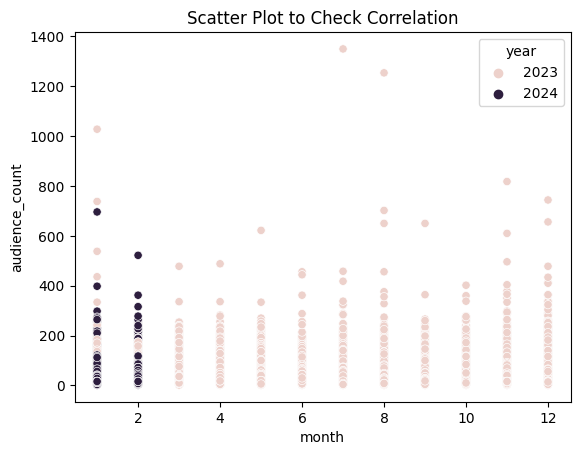

In [20]:
sns.scatterplot(data=df[['audience_count','month', 'year']].dropna(), x='month',
             y='audience_count',hue = 'year' )
plt.title("Scatter Plot to Check Correlation")
plt.show()

<Axes: xlabel='audience_count', ylabel='Count'>

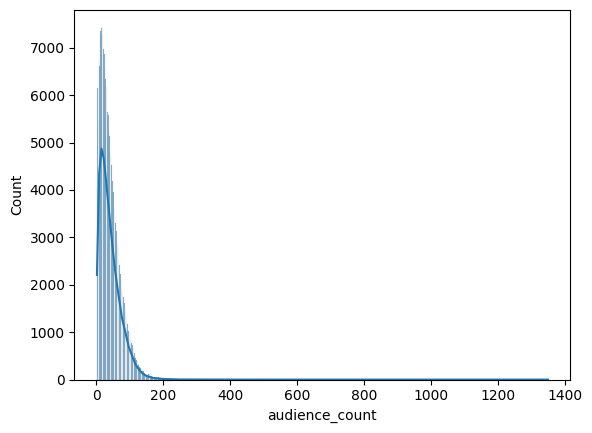

In [21]:
sns.histplot(df['audience_count'], kde = True)

count 375


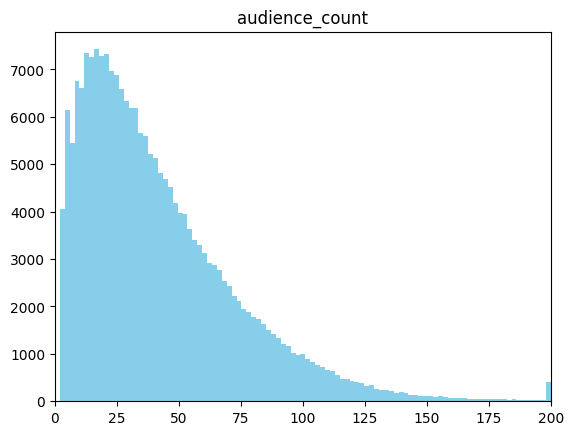

In [22]:
print('count',df[df['audience_count']>200]['audience_count'].count())
plt.hist( df['audience_count'].apply(lambda x: x if x < 200 else 200), bins=100, color='skyblue')
plt.xlim(0,200)
plt.title("audience_count")

plt.show()

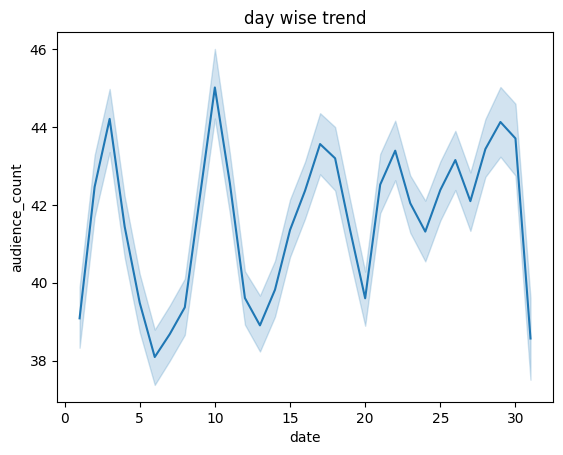

In [23]:
sns.lineplot(data=df[['audience_count','month', 'date']].dropna(), x='date',
             y='audience_count' )
plt.title("day wise trend")
plt.show()

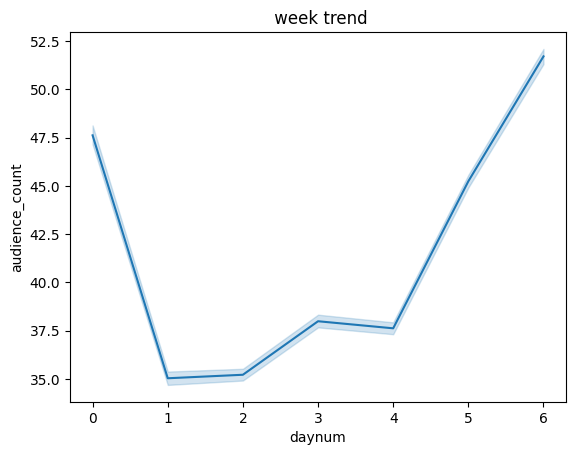

In [24]:
sns.lineplot(data=df[['audience_count','month', 'date','daynum']].dropna(), x='daynum',
             y='audience_count' )
plt.title(" week trend")
plt.show()

# Validation Dataset

In [25]:
submission['book_theater_id'] = submission['ID'].apply(lambda x : x[5:10]).astype(int)
submission['date'] = submission['ID'].apply(lambda x : x[11:])
print(min(submission['date'])), print(max(submission['date']))
submission.head()

2024-03-01
2024-04-22


,ID,audience_count,book_theater_id,date
0,book_00001_2024-03-01,0,1,2024-03-01
1,book_00001_2024-03-02,0,1,2024-03-02
2,book_00001_2024-03-03,0,1,2024-03-03
3,book_00001_2024-03-04,0,1,2024-03-04
4,book_00001_2024-03-06,0,1,2024-03-06


In [26]:
# Data frame creation for getting same column names as training
details_df = df.groupby(['book_theater_id','theater_type_x','theater_area_x'
                        ,'latitude_x',
                   'longitude_x']).size().reset_index()
details_df.head()

,book_theater_id,theater_type_x,theater_area_x,latitude_x,longitude_x,0
0,1,Drama,2,23.004410,79.934515,342
1,2,Other,27,22.611676,78.228299,288
2,3,Other,25,26.249437,80.979803,240
3,4,Other,29,24.048814,80.382037,366
4,5,Action,8,22.495681,77.015883,243


## Feature Engineering

In [27]:
submission['show_date'] = pd.to_datetime(submission['date'],errors='coerce')
submission['is_weekday'] = submission['show_date'].dt.weekday < 5
submission['is_weekday']= submission['is_weekday'].astype(int)

submission['year'] = submission['show_date'].dt.year
submission['month'] = submission['show_date'].dt.month
submission['date'] = submission['show_date'].dt.day
submission['daynum'] = submission['show_date'].dt.dayofweek

submission= pd.merge(submission,details_df,how = 'left', on = ['book_theater_id'])

submission['theater_type_x'] = submission['theater_type_x'].fillna(df['theater_type_x'].mode()[0])
submission['theater_area_x'] = submission['theater_area_x'].fillna(df['theater_area_x'].mode()[0])

latitude_mapping = (
    df[df['latitude_x'].notna()].groupby('theater_area_x')['latitude_x']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
)

longitude_mapping = (
    df[df['longitude_x'].notna()].groupby('theater_area_x')['longitude_x']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
)

submission['latitude_x'] = submission['latitude_x'].fillna(submission['theater_area_x'].map(latitude_mapping))
submission['longitude_x'] = submission['longitude_x'].fillna(submission['theater_area_x'].map(longitude_mapping))

submission.head()

,ID,audience_count,book_theater_id,date,show_date,is_weekday,year,month,daynum,theater_type_x,theater_area_x,latitude_x,longitude_x,0
0,book_00001_2024-03-01,0,1,1,2024-03-01,1,2024,3,4,Drama,2.0,23.00441,79.934515,342.0
1,book_00001_2024-03-02,0,1,2,2024-03-02,0,2024,3,5,Drama,2.0,23.00441,79.934515,342.0
2,book_00001_2024-03-03,0,1,3,2024-03-03,0,2024,3,6,Drama,2.0,23.00441,79.934515,342.0
3,book_00001_2024-03-04,0,1,4,2024-03-04,1,2024,3,0,Drama,2.0,23.00441,79.934515,342.0
4,book_00001_2024-03-06,0,1,6,2024-03-06,1,2024,3,2,Drama,2.0,23.00441,79.934515,342.0


## Lag Features and union

In [28]:
# Creating lag features

col = ['book_theater_id', 'show_date','theater_type_x',
         'is_weekday','year', 'month', 'date', 'daynum',
        'latitude_x','longitude_x',
        'theater_area_x','audience_count']

lag_df = df[col]

# Lag and submission dataset union

lag_df['show_date'] = pd.to_datetime(lag_df['show_date'])

lag_df = pd.concat(
    [lag_df[col], submission[col]],
    axis=0
).reset_index(drop=True)

lag_df = lag_df.sort_values(['book_theater_id','show_date'])

# Adding lag Features

lag_features = [1, 2, 7]
for lag in lag_features:
    lag_df[f'lag_{lag}'] = lag_df.groupby('book_theater_id')['audience_count'].shift(lag)
lag_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 252252 entries, 0 to 252251
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  252252 non-null  int64         
 1   show_date        252252 non-null  datetime64[ns]
 2   theater_type_x   252252 non-null  object        
 3   is_weekday       252252 non-null  int64         
 4   year             252252 non-null  int32         
 5   month            252252 non-null  int32         
 6   date             252252 non-null  int32         
 7   daynum           252252 non-null  int32         
 8   latitude_x       252252 non-null  float64       
 9   longitude_x      252252 non-null  float64       
 10  theater_area_x   252252 non-null  float64       
 11  audience_count   252252 non-null  int64         
 12  lag_1            251423 non-null  float64       
 13  lag_2            250594 non-null  float64       
 14  lag_7            246449 n

/tmp/ipykernel_13/863991870.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lag_df['show_date'] = pd.to_datetime(lag_df['show_date'])


## Imputation of missing values in lag columns

In [29]:
id_lag_map = lag_df[lag_df['audience_count'] != 0].groupby('book_theater_id')['audience_count'].mean().to_dict()
area_lag_map = lag_df[lag_df['audience_count'] != 0].groupby('theater_area_x')['audience_count'].mean().to_dict()
global_mean = lag_df[lag_df['audience_count'] != 0]['audience_count'].mean()

def lag_map(col_list,lag_df,area_lag_map,id_lag_map):
    for col in col_list:
        lag_df[col] = lag_df.apply(
                lambda x: (
                    id_lag_map.get(x['book_theater_id'],
                                    area_lag_map.get(x['theater_area_x'], global_mean)
                                  )
                if pd.isna(x[col]) else x[col]
            ),
            axis=1
        )

lag_map(['lag_1','lag_2','lag_7'],lag_df,area_lag_map,id_lag_map)

In [30]:
print(df[df['year'] == 2023]['book_theater_id'].nunique())
print(df[df['year'] == 2024]['book_theater_id'].nunique())

id_2023 = set(df[df['year'] == 2023]['book_theater_id'].unique())

id_2024 = set(df[df['year'] == 2024]['book_theater_id'].unique())

diff = set.difference(id_2024,id_2023)
df[df['book_theater_id'].isin(diff)]

819
818


,book_theater_id,show_date,audience_count,tickets_booked,theater_type_x,theater_area_x,latitude_x,longitude_x,tickets_sold,is_weekday,year,month,date,daynum,week
26365,105,2024-02-15,10,44.0,Other,59,22.165811,76.204447,4.0,1,2024,2,15,3,7
38968,152,2024-01-27,8,13.0,Drama,2,23.004410,79.934515,8.0,0,2024,1,27,5,4
38969,152,2024-01-30,8,7.0,Drama,2,23.004410,79.934515,3.0,1,2024,1,30,1,5
38970,152,2024-01-31,4,7.0,Drama,2,23.004410,79.934515,5.0,1,2024,1,31,2,5
38971,152,2024-02-01,6,7.0,Drama,2,23.004410,79.934515,4.0,1,2024,2,1,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149094,581,2024-02-24,62,12.0,Other,3,23.005894,79.915496,6.0,0,2024,2,24,5,8
149095,581,2024-02-25,70,16.0,Other,3,23.005894,79.915496,6.0,0,2024,2,25,6,8
149096,581,2024-02-26,70,10.0,Other,3,23.005894,79.915496,4.0,1,2024,2,26,0,9
149097,581,2024-02-27,66,8.0,Other,3,23.005894,79.915496,4.0,1,2024,2,27,1,9


# AI Model Training

## Train / Test Split

In [31]:
x= lag_df[lag_df['audience_count'] != 0].drop(columns = ['show_date','audience_count'])
y = lag_df[lag_df['audience_count'] != 0]['audience_count']

x_train = lag_df[(lag_df['audience_count'] != 0) & (lag_df['show_date'] <= '2024-01-31')
                ].drop(columns = ['show_date','audience_count'])
y_train = lag_df[(lag_df['audience_count'] != 0) & (lag_df['show_date'] <= '2024-01-31')
                ]['audience_count']

x_test = lag_df[(lag_df['audience_count'] != 0) & (lag_df['show_date'] > '2024-01-31')
                ].drop(columns = ['show_date','audience_count'])
y_test = lag_df[(lag_df['audience_count'] != 0) & (lag_df['show_date'] > '2024-01-31')
                ]['audience_count']

## Custom Encoding Class

In [32]:
from sklearn.base import BaseEstimator, TransformerMixin

class CustomEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, encode_col=None,
                 backup_col=None,
                 strategy = None,
                 create_new_column = 'Y'
                ):
        self.encode_col = encode_col
        self.backup_col = backup_col
        self.encode_map = None
        self.backup_map = None
        self.global_mean = None
        self.strategy = strategy
        self.create_new_column = create_new_column

    def fit(self, X, y):
        df = X.copy()
        df['target'] = y

        if self.strategy == 'median':
            self.global_mean = y.median()
            self.encode_map = df.groupby(self.encode_col)['target'].median().to_dict()
            self.backup_map = df.groupby(self.backup_col)['target'].median().to_dict()
        elif self.strategy == 'mean':
            self.global_mean = y.mean()
            self.encode_map = df.groupby(self.encode_col)['target'].mean().to_dict()
            self.backup_map = df.groupby(self.backup_col)['target'].mean().to_dict()
        else:
            self.global_mean = y.mode()
            self.encode_map = df.groupby(self.encode_col)['target'].mode().to_dict()
            self.backup_map = df.groupby(self.backup_col)['target'].mode().to_dict()

        return self

    def transform(self, X):
        X = X.copy()

        if self.create_new_column == 'Y':
            col_name = f'{self.encode_col}_1'
        else:
            col_name = f'{self.encode_col}'

        X[col_name] = X[self.encode_col].map(self.encode_map)

        X[col_name] = X.apply(
            lambda row: self.backup_map.get(row[self.backup_col], self.global_mean)
            if pd.isna(row[col_name]) else row[col_name],
            axis=1
        )

        return X

## Gradient Boosting

In [33]:
gbr_model = GradientBoostingRegressor(random_state=42)

feature_columns = [
    'is_weekday', 'year', 'month', 'date', 'daynum',
    'latitude_x', 'longitude_x',
    'book_theater_id', 'theater_area_x', 'theater_type_x',
    'lag_1', 'lag_2', 'lag_7'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('one_hot_encoding', OneHotEncoder(handle_unknown='ignore'), ['theater_type_x'])
    ],
    remainder='passthrough'
)

gbr_pipeline = Pipeline(steps=[
    ('target_encoding', CustomEncoder(
        encode_col='book_theater_id',
        backup_col='theater_area_x',
        strategy='mean'
    )),
    ('preprocessing', preprocessor),
    ('regressor', gbr_model)
])

gbr_param_search_space = {
    'regressor__n_estimators': [100, 200, 300, 400],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_depth': [3, 4, 5, 6],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', None]
}

gbr_search = RandomizedSearchCV(
    estimator=gbr_pipeline,
    param_distributions=gbr_param_search_space,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

gbr_search.fit(x_train[feature_columns], y_train)

best_gbr_model = gbr_search.best_estimator_

print("Best Hyperparameters:", gbr_search.best_params_)

gbr_test_predictions = best_gbr_model.predict(x_test[feature_columns])
print("Test R² Score:", r2_score(y_test, gbr_test_predictions))
print("Test MSE:", mean_squared_error(y_test, gbr_test_predictions))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'regressor__subsample': 1.0, 'regressor__n_estimators': 100, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 4, 'regressor__max_features': 'log2', 'regressor__max_depth': 3, 'regressor__learning_rate': 0.05}
Test R² Score: 0.5111297767361038
Test MSE: 467.05176721274233


In [34]:
# gbr_model = GradientBoostingRegressor(random_state=42)

# gbr_best_params = {
#     'regressor__subsample': 1.0,
#     'regressor__n_estimators': 400,
#     'regressor__min_samples_split': 2,
#     'regressor__min_samples_leaf': 4,
#     'regressor__max_features': 'log2',
#     'regressor__max_depth': 6,
#     'regressor__learning_rate': 0.1
# }

# feature_columns = [
#     'is_weekday', 'year', 'month', 'date', 'daynum',
#     'latitude_x', 'longitude_x',
#     'book_theater_id', 'theater_area_x', 'theater_type_x',
#     'lag_1', 'lag_2', 'lag_7'
# ]

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('one_hot_encoding', OneHotEncoder(handle_unknown='ignore'), ['theater_type_x'])
#     ],
#     remainder='passthrough'
# )

# gbr_pipeline = Pipeline(steps=[
#     ('target_encoding', CustomEncoder(
#         encode_col='book_theater_id',
#         backup_col='theater_area_x',
#         strategy='mean'
#     )),
#     ('preprocessing', preprocessor),
#     ('regressor', gbr_model)
# ])

# gbr_pipeline.set_params(**gbr_best_params)
# gbr_pipeline.fit(x_train[feature_columns], y_train)

# gbr_test_predictions = gbr_pipeline.predict(x_test[feature_columns])
# print("Test R² Score:", r2_score(y_test, gbr_test_predictions))
# print("Test MSE:", mean_squared_error(y_test, gbr_test_predictions))

### Refit on complete dataset

In [35]:
gbr_pipeline.fit(x[feature_columns], y)
gbr_final_predictions = gbr_pipeline.predict(x[feature_columns])

print("Refit scores on all data")
print("R² Score:", r2_score(y, gbr_final_predictions))
print("MSE:", mean_squared_error(y, gbr_final_predictions))

Refit scores on all data
R² Score: 0.49582160379671625
MSE: 543.5682267220059


## Xgboost

In [36]:
feature_columns = [
    'is_weekday', 'year', 'month', 'date', 'daynum',
    'latitude_x', 'longitude_x',
    'book_theater_id', 'theater_area_x', 'theater_type_x',
    'lag_1', 'lag_2', 'lag_7'
]

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)

xgb_preprocessor = ColumnTransformer(
    transformers=[
        ('one_hot_encoding', OneHotEncoder(handle_unknown='ignore'), ['theater_type_x'])
    ],
    remainder='passthrough'
)

xgb_pipeline = Pipeline(steps=[
    ('target_encoding', CustomEncoder(
        encode_col='book_theater_id',
        backup_col='theater_area_x',
        strategy='mean',
        create_new_column='Y'
    )),
    ('preprocessing', xgb_preprocessor),
    ('regressor', xgb_model)
])

xgb_param_space = {
    'regressor__n_estimators': [150, 200, 300, 350],
    'regressor__max_depth': [8, 10, 12, 14],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 1.0],
    'regressor__gamma': [0.05, 0.1, 0.5],
    'regressor__reg_alpha': [0.1, 1, 2],
    'regressor__reg_lambda': [1.5, 2, 3]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_space,
    n_iter=50,
    random_state=42,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(x_train[feature_columns], y_train)

best_xgb_model = xgb_search.best_estimator_
print("Best Params:", xgb_search.best_params_)

xgb_test_predictions = best_xgb_model.predict(x_test[feature_columns])
print("Test R² Score:", r2_score(y_test, xgb_test_predictions))
print("Test MSE Score:", mean_squared_error(y_test, xgb_test_predictions))

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'regressor__subsample': 0.6, 'regressor__reg_lambda': 1.5, 'regressor__reg_alpha': 0.1, 'regressor__n_estimators': 350, 'regressor__max_depth': 10, 'regressor__learning_rate': 0.01, 'regressor__gamma': 0.05, 'regressor__colsample_bytree': 0.7}
Test R² Score: 0.5555860572708476
Test MSE Score: 424.5795866638171


In [37]:
# feature_columns = [
#     'is_weekday', 'year', 'month', 'date', 'daynum',
#     'latitude_x', 'longitude_x',
#     'book_theater_id', 'theater_area_x', 'theater_type_x',
#     'lag_1', 'lag_2', 'lag_7'
# ]

# xgb_best_params = {
#     'regressor__subsample': 0.8,
#     'regressor__reg_lambda': 2,
#     'regressor__reg_alpha': 1,
#     'regressor__n_estimators': 150,
#     'regressor__max_depth': 14,
#     'regressor__learning_rate': 0.01,
#     'regressor__gamma': 0.05,
#     'regressor__colsample_bytree': 0.7
# }

# xgb_preprocessor = ColumnTransformer(
#     transformers=[
#         ('one_hot_encoding', OneHotEncoder(handle_unknown='ignore'), ['theater_type_x'])
#     ],
#     remainder='passthrough'
# )

# xgb_model = XGBRegressor(
#     objective='reg:squarederror',
#     random_state=42,
#     verbosity=0,
#     **xgb_best_params
# )

# xgb_pipeline = Pipeline(steps=[
#     ('target_encoding', CustomEncoder(
#         encode_col='book_theater_id',
#         backup_col='theater_area_x',
#         strategy='mean'
#     )),
#     ('preprocessing', xgb_preprocessor),
#     ('regressor', xgb_model)
# ])

# xgb_pipeline.fit(x_train[feature_columns], y_train)

# xgb_test_predictions = xgb_pipeline.predict(x_test[feature_columns])
# print("Test R² Score:", r2_score(y_test, xgb_test_predictions))
# print("Test MSE Score:", mean_squared_error(y_test, xgb_test_predictions))

### Refit on complete dataset

In [38]:
xgb_pipeline.fit(x[feature_columns], y)

xgb_final_predictions = xgb_pipeline.predict(x[feature_columns])

print("Refit scores on all the data")
print("Train R² Score:", r2_score(y, xgb_final_predictions))
print("Train MSE Score:", mean_squared_error(y, xgb_final_predictions))

Refit scores on all the data
Train R² Score: 0.6030937974784516
Train MSE Score: 427.91520284144656


## Light GBM

In [39]:
feature_columns = [
    'is_weekday', 'year', 'month', 'date', 'daynum',
    'latitude_x', 'longitude_x',
    'book_theater_id', 'theater_area_x', 'theater_type_x',
    'lag_1', 'lag_2', 'lag_7'
]

lgb_model = LGBMRegressor(
    force_row_wise=False,
    random_state=42,
    verbose=-1
)

lgb_preprocessor = ColumnTransformer(
    transformers=[
        ('one_hot_encoding', OneHotEncoder(handle_unknown='ignore'), ['theater_type_x'])
    ],
    remainder='passthrough'
)

lgb_pipeline = Pipeline(steps=[
    ('target_encoding', CustomEncoder(
        encode_col='book_theater_id',
        backup_col='theater_area_x',
        strategy='mean'
    )),
    ('preprocessing', lgb_preprocessor),
    ('regressor', lgb_model)
])

lgb_param_space = {
    'regressor__n_estimators': [200, 400, 600],
    'regressor__max_depth': [8, 10, 20],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__num_leaves': [31, 63, 127],
    'regressor__min_child_samples': [5, 10, 20],
    'regressor__min_child_weight': [0.001, 0.01, 0.1],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0],
    'regressor__reg_alpha': [0, 0.1],
    'regressor__reg_lambda': [0.5, 1]
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_pipeline,
    param_distributions=lgb_param_space,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=-1,
    n_jobs=-1,
    random_state=42
)

lgb_search.fit(x_train[feature_columns], y_train)

best_lgb_model = lgb_search.best_estimator_
print("Best LGBM Params:", lgb_search.best_params_)

lgb_test_predictions = best_lgb_model.predict(x_test[feature_columns])
print("LGB Performance:")
print("R² Score:", r2_score(y_test, lgb_test_predictions))
print("MSE:", mean_squared_error(y_test, lgb_test_predictions))

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best LGBM Params: {'regressor__subsample': 0.8, 'regressor__reg_lambda': 1, 'regressor__reg_alpha': 0, 'regressor__num_leaves': 31, 'regressor__n_estimators': 200, 'regressor__min_child_weight': 0.001, 'regressor__min_child_samples': 20, 'regressor__max_depth': 10, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.8}
LGB Performance:
R² Score: 0.527313092198928
MSE: 451.5907190110128


In [40]:
# feature_columns = [
#     'is_weekday', 'year', 'month', 'date', 'daynum',
#     'latitude_x', 'longitude_x',
#     'book_theater_id', 'theater_area_x', 'theater_type_x',
#     'lag_1', 'lag_2', 'lag_7'
# ]

# lgb_config = {
#     'regressor__subsample': 0.8,
#     'regressor__reg_lambda': 2,
#     'regressor__reg_alpha': 1,
#     'regressor__n_estimators': 150,
#     'regressor__max_depth': 14,
#     'regressor__learning_rate': 0.05,
#     'regressor__gamma': 0.05,
#     'regressor__colsample_bytree': 0.7
# }

# lgb_model = LGBMRegressor(
#     force_row_wise=True,
#     random_state=42,
#     verbose=-1,
#     **lgb_config
# )

# lgb_preprocessor = ColumnTransformer(
#     transformers=[
#         ('one_hot_encoding', OneHotEncoder(handle_unknown='ignore'), ['theater_type_x'])
#     ],
#     remainder='passthrough'
# )

# lgb_pipeline = Pipeline(steps=[
#     ('target_encoding', CustomEncoder(
#         encode_col='book_theater_id',
#         backup_col='theater_area_x',
#         strategy='mean',
#         create_new_column='N'
#     )),
#     ('preprocessing', lgb_preprocessor),
#     ('regressor', lgb_model)
# ])

# lgb_pipeline.fit(x_train[feature_columns], y_train)

# lgb_test_predictions = lgb_pipeline.predict(x_test[feature_columns])
# print("Test R² Score:", r2_score(y_test, lgb_test_predictions))
# print("Test MSE Score:", mean_squared_error(y_test, lgb_test_predictions))

### Refit on complete dataset

In [41]:
lgb_pipeline.fit(x[feature_columns], y)

lgb_final_predictions = lgb_pipeline.predict(x[feature_columns])

print("Refit scores on all the data")
print("Train R² Score:", r2_score(y, lgb_final_predictions))
print("Train MSE Score:", mean_squared_error(y, lgb_final_predictions))

Refit scores on all the data
Train R² Score: 0.5364031225228402
Train MSE Score: 499.81620494209807


## Voting Regressor
An ensemble model is used for using the best of all the three above trained models to see if their combination/ensemble gives better results or not.

In [42]:
from sklearn.ensemble import VotingRegressor

voter = VotingRegressor([
    ('gb', gbr_pipeline),
    ('xgb', xgb_pipeline),
    ('lgb', lgb_pipeline)
])

voter.fit(x_train[feature_columns], y_train)

voter_test_predictions = voter.predict(x_test[feature_columns])
print("Test R² Score:", r2_score(y_test, voter_test_predictions))
print("Test MSE Score:", mean_squared_error(y_test, voter_test_predictions))

Test R² Score: 0.5318793869899335
Test MSE Score: 447.22821961901724


# Comparison

In [43]:
models = {
    'Gradient Boosting': {
        'predictions': gbr_test_predictions,
        'y_true': y_test
    },
    'XGBoost': {
        'predictions': xgb_test_predictions,
        'y_true': y_test
    },
    'LightGBM': {
        'predictions': lgb_test_predictions,
        'y_true': y_test
    },
    'Voting Regressor': {
        'predictions': voter_test_predictions,
        'y_true': y_test
    }
}

performance_metrics = []

for name, data in models.items():
    y_true = data['y_true']
    y_pred = data['predictions']

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    performance_metrics.append({
        'Model': name,
        'R2 Score': r2,
        'MSE': mse
    })

comparison_df = pd.DataFrame(performance_metrics)
print("\n--- Model Performance Comparison ---")
print(comparison_df.sort_values(by='R2 Score', ascending=False))


--- Model Performance Comparison ---
               Model  R2 Score         MSE
1            XGBoost  0.555586  424.579587
3   Voting Regressor  0.531879  447.228220
2           LightGBM  0.527313  451.590719
0  Gradient Boosting  0.511130  467.051767


# Final Prediction

In [44]:
best_model_row = comparison_df.sort_values(by='R2 Score', ascending=False).iloc[0]
best_model_name = best_model_row['Model']

final_predictor = None
cols_for_prediction = None

if best_model_name == 'Gradient Boosting':
    final_predictor = gbr_pipeline
    cols_for_prediction = feature_columns
elif best_model_name == 'XGBoost':
    final_predictor = xgb_pipeline
    cols_for_prediction = feature_columns
elif best_model_name == 'LightGBM':
    final_predictor = lgb_pipeline
    cols_for_prediction = feature_columns
elif best_model_name == 'Voting Regressor':
    final_predictor = voter
    cols_for_prediction = feature_columns

if final_predictor is None:
    raise ValueError(f"Could not identify the best model: {best_model_name}")

for idx in lag_df.index[lag_df["audience_count"] == 0]:
    t_id = lag_df.loc[idx, "book_theater_id"]
    theater_data = lag_df[lag_df["book_theater_id"] == t_id].loc[:idx]

    lag_features = [1, 2, 7]
    for lag in lag_features:
        if lag_df.loc[idx, f"lag_{lag}"] == 0:
            if len(theater_data) > lag:
                lag_df.loc[idx, f"lag_{lag}"] = theater_data.iloc[-lag - 1]["audience_count"]
    lag_df.loc[idx, "audience_count"] = final_predictor.predict(
        lag_df.loc[[idx],  cols_for_prediction]
    )[0]

In [45]:
submission_df = pd.merge(submission,lag_df,how="left",on=['book_theater_id','show_date'])
submission_df = submission_df [['ID','audience_count_y']]
submission_df.columns = ['ID', 'audience_count']
submission_df['audience_count'] = np.round(submission_df['audience_count'])
submission_df.head()
submission_df.to_csv('submission.csv', index=False)